# Attention experiment nu/d

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [25]:
N = 200
d = 100
nu_over_d_X = 0.9
nu_over_d_K = 0.9
nu_over_d_Q = 0.9
nu_over_d_V = 0.9
verbose = True
uniform_draws = True
use_pareto = True
use_uniform = False
use_cauchy = False
use_svd = True

xx = pp.attention_experiment_nu_over_d(N, d, nu_over_d_X, nu_over_d_K, nu_over_d_Q, nu_over_d_V, verbose, uniform_draws, use_pareto, use_uniform, use_cauchy, use_svd)

using pareto
[1.00290877 1.00585535 1.00884065 1.01186556 1.01493103]
generate_data_manifold: using svd
using pareto
[1.00290877 1.00585535 1.00884065 1.01186556 1.01493103]
 ** generate_square_weight_matrix: using GPU **
using pareto
[1.00290877 1.00585535 1.00884065 1.01186556 1.01493103]
 ** generate_square_weight_matrix: using GPU **
using pareto
[1.00290877 1.00585535 1.00884065 1.01186556 1.01493103]
 ** generate_square_weight_matrix: using GPU **
alpha_X =  3.42578142608798 , pp_dim_X =  89.58809123671195 , nu_over_d_X =  0.8958809123671194 , implied_alpha_X =  3.357340268323647
alpha_K =  3.42578142608798 , pp_dim_WK =  88.766306507685 , nu_over_d_WK =  0.88766306507685 , implied_alpha_K =  3.2328812955282378
alpha_Q =  3.42578142608798 , pp_dim_WQ =  88.76830310672513 , nu_over_d_WQ =  0.8876830310672513 , implied_alpha_Q =  3.2331661338186297
alpha_V =  3.42578142608798 , pp_dim_WV =  88.74772579927473 , nu_over_d_WV =  0.8874772579927473 , implied_alpha_V =  3.23023435820894

In [15]:
num_iterations = 100
scale_factor = 200


verbose = True
uniform_draws = True
use_pareto = True
use_uniform = False
use_cauchy = False
use_svd = True

actual_nu_over_d_AttnQKV_vals = np.zeros(num_iterations) 
estimate_nu_over_d_AttnQKV_vals = np.zeros(num_iterations)
pure_estimate_nu_over_d_AttnQKV_vals = np.zeros(num_iterations)
new_estimate_nu_over_d_AttnQKV_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    N = int(scale_factor * (3.0 + 2.0 * np.random.uniform(0,1)))
    d = N - int(scale_factor * (1.0 + np.random.uniform(0,1)))
    nu_over_d = math.sqrt(np.random.uniform(0,1))
    print(i, N, d, nu_over_d)

    nu_over_d_X = math.sqrt(np.random.uniform(0,1))
    nu_over_d_K = math.sqrt(np.random.uniform(0,1))
    nu_over_d_Q = math.sqrt(np.random.uniform(0,1))
    nu_over_d_V = math.sqrt(np.random.uniform(0,1))

    xx = pp.attention_experiment_nu_over_d(N, d, nu_over_d_X, nu_over_d_K, nu_over_d_Q, nu_over_d_V, verbose, uniform_draws, use_pareto, use_uniform, use_cauchy, use_svd)

    actual_nu_over_d_AttnQKV = xx["actual_nu_over_d_AttnQKV"]
    estimate_nu_over_d_AttnQKV = xx["estimate_nu_over_d_AttnQKV"]
    pure_estimate_nu_over_d_AttnQKV = xx["pure_estimate_nu_over_d_AttnQKV"]
    new_estimate_nu_over_d_AttnQKV = xx["new_estimate_nu_over_d_AttnQKV"]

    actual_nu_over_d_AttnQKV_vals[i] = actual_nu_over_d_AttnQKV
    estimate_nu_over_d_AttnQKV_vals[i] = estimate_nu_over_d_AttnQKV
    pure_estimate_nu_over_d_AttnQKV_vals[i] = pure_estimate_nu_over_d_AttnQKV
    new_estimate_nu_over_d_AttnQKV_vals[i] = new_estimate_nu_over_d_AttnQKV
    

0 912 656 0.6438394659169383
using pareto
[1.00092548 1.00185323 1.00278325 1.00371557 1.00465019]
generate_data_manifold: using svd
using pareto
[1.00045176 1.00090441 1.00135797 1.00181242 1.00226777]
 ** generate_square_weight_matrix: using GPU **
using pareto
[1.00069963 1.00140081 1.00210356 1.00280788 1.00351378]
 ** generate_square_weight_matrix: using GPU **
using pareto
[1.00056381 1.0011288  1.00169497 1.00226233 1.00283089]
 ** generate_square_weight_matrix: using GPU **
alpha_X =  1.6466451087138896 , pp_dim_X =  227.56972414337358 , nu_over_d_X =  0.346905067291728 , implied_alpha_X =  1.5702636302776602
alpha_K =  3.3725263581173928 , pp_dim_WK =  563.2504575354593 , nu_over_d_WK =  0.8586135023406392 , implied_alpha_K =  3.283823879786606
alpha_Q =  2.1779618961609253 , pp_dim_WQ =  399.9340279478567 , nu_over_d_WQ =  0.6096555304083181 , implied_alpha_Q =  2.098658626666999
alpha_V =  2.7024286133468185 , pp_dim_WV =  498.89139020831834 , nu_over_d_WV =  0.7605051680004

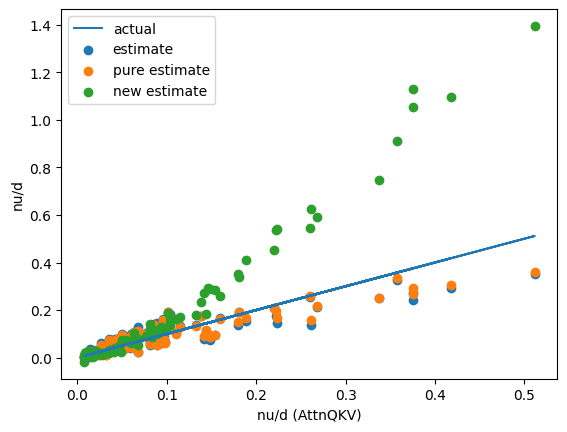

In [16]:
plt.plot(actual_nu_over_d_AttnQKV_vals, actual_nu_over_d_AttnQKV_vals, label = "actual")
plt.scatter(actual_nu_over_d_AttnQKV_vals, estimate_nu_over_d_AttnQKV_vals, label = "estimate")
plt.scatter(actual_nu_over_d_AttnQKV_vals, pure_estimate_nu_over_d_AttnQKV_vals, label = "pure estimate")
plt.scatter(actual_nu_over_d_AttnQKV_vals, new_estimate_nu_over_d_AttnQKV_vals, label = "new estimate")
plt.xlabel("nu/d (AttnQKV)")
plt.ylabel("nu/d")
plt.legend()
plt.show()

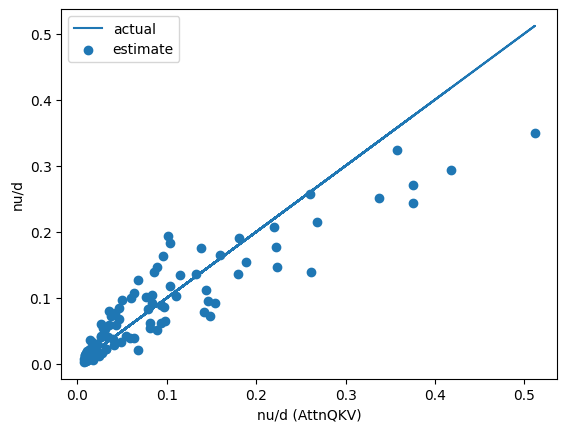

In [17]:
plt.plot(actual_nu_over_d_AttnQKV_vals, actual_nu_over_d_AttnQKV_vals, label = "actual")
plt.scatter(actual_nu_over_d_AttnQKV_vals, estimate_nu_over_d_AttnQKV_vals, label = "estimate")
#plt.scatter(actual_nu_over_d_AttnQKV_vals, pure_estimate_nu_over_d_AttnQKV_vals, label = "pure estimate")
#plt.scatter(actual_nu_over_d_AttnQKV_vals, new_estimate_nu_over_d_AttnQKV_vals, label = "new estimate")
plt.xlabel("nu/d (AttnQKV)")
plt.ylabel("nu/d")
plt.legend()
plt.show()

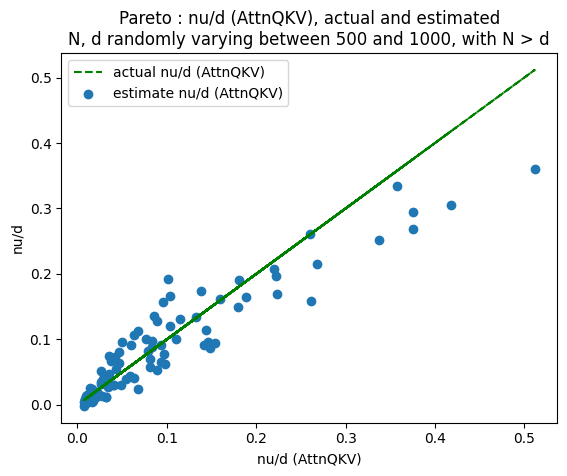

In [27]:
this_title = "Pareto : nu/d (AttnQKV), actual and estimated\n"
this_title += "N, d randomly varying between 500 and 1000, with N > d"

plt.plot(actual_nu_over_d_AttnQKV_vals, actual_nu_over_d_AttnQKV_vals, linestyle = "--", color = "green", label = "actual nu/d (AttnQKV)")
#plt.scatter(actual_nu_over_d_AttnQKV_vals, estimate_nu_over_d_AttnQKV_vals, label = "estimate")
plt.scatter(actual_nu_over_d_AttnQKV_vals, pure_estimate_nu_over_d_AttnQKV_vals, label = "estimate nu/d (AttnQKV)")
#plt.scatter(actual_nu_over_d_AttnQKV_vals, new_estimate_nu_over_d_AttnQKV_vals, label = "new estimate")
plt.xlabel("nu/d (AttnQKV)")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_AttnQKV_actual_vs_pure_estimate_pareto.pdf', dpi=300, bbox_inches='tight')
plt.show()

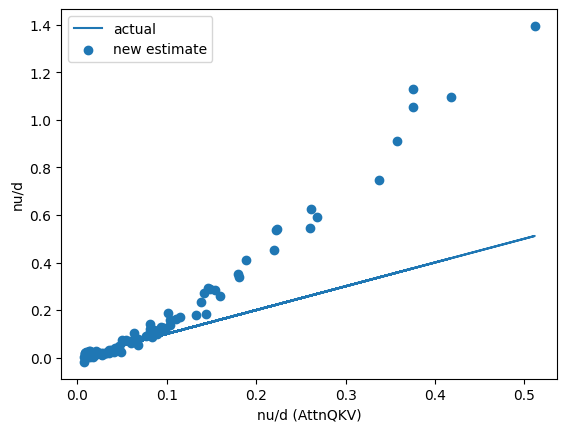

In [22]:
plt.plot(actual_nu_over_d_AttnQKV_vals, actual_nu_over_d_AttnQKV_vals, label = "actual")
#plt.scatter(actual_nu_over_d_AttnQKV_vals, estimate_nu_over_d_AttnQKV_vals, label = "estimate")
#plt.scatter(actual_nu_over_d_AttnQKV_vals, pure_estimate_nu_over_d_AttnQKV_vals, label = "pure estimate")
plt.scatter(actual_nu_over_d_AttnQKV_vals, new_estimate_nu_over_d_AttnQKV_vals, label = "new estimate")
plt.xlabel("nu/d (AttnQKV)")
plt.ylabel("nu/d")
plt.legend()
plt.show()

In [ ]:
# actual_nu_over_d_AttnQKV =  0.40044720005034806 
# estimate_nu_over_d_AttnQKV =  0.2930212385717338
# pure_estimate_nu_over_d_AttnQKV =  0.292411771408826